In [1]:
import torch
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
use_cuda = torch.cuda.is_available()
print(use_cuda)

Sun Jun  7 00:21:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:01:00.0  On |                  N/A |
| 35%   43C    P8             27W /  350W |     652MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

安装torch指令:

In [2]:
# !pip install torch==2.0.0+cu118 torchvision==0.15.1+cu118 torchaudio==2.0.1+cu118 -f https://download.pytorch.org/whl/torch_stable.html

In [2]:
SEED = 42
WEIGHTED = True

In [3]:
from datasets import *
import pandas as pd
import numpy as np
train = pd.DataFrame(load_dataset("public_data/train/track_a/eng", split="train"))
bias_AC=[]
bias_DI=[]
bias_ANB=[]
for i in range(len(train)):
    bias_AC.append(int(train['bias_labels'][i][1]))
    bias_DI.append(int(train['bias_labels'][i][4]))
    bias_ANB.append(int(train['bias_labels'][i][7]))
train['bias_AC']=bias_AC
train['bias_DI']=bias_DI
train['bias_ANB']=bias_ANB
train.head()

D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ori_sentence,bias_labels,bias_AC,bias_DI,bias_ANB
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,"[0, 1, 0]",0,1,0
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,"[0, 1, 1]",0,1,1
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,"[0, 1, 0]",0,1,0
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,"[1, 0, 0]",1,0,0
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,"[1, 1, 0]",1,1,0


In [4]:
labels = ["bias_AC", "bias_DI", "bias_ANB"]
def get_text_and_label(df):
  return df.rename(columns={"ori_sentence": "ori_sentence"})[["ori_sentence"] + labels]
train = get_text_and_label(train)
val = get_text_and_label(train)
test = get_text_and_label(train)
print(f"Dataset size: <{len(train.index)}:{len(val.index)}:{len(test.index)}>")
train.head(10)

Dataset size: <25590:25590:25590>


,ori_sentence,bias_AC,bias_DI,bias_ANB
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,0,1,0
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,0,1,1
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,0,1,0
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,1,0,0
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,1,1,0
5,懂什么叫爱情，不懂你说的那个爱情。他对你，是不是跟你待他的心肠一样呢？”“我不知道，我不知道...,0,1,0
6,流苏在那里看她，她也昂然望着流苏，那一双骄矜的眼睛，如同隔着几千里地，远远的向人望过来。,0,1,0
7,这思想开始火焰似的把她燃烧起来了，她再也克制不住自己了，骄傲，自尊，虚荣，矜持……全都冰消瓦解了。,0,1,0
8,门岗的小兵说：“没有借书证我不会放你们进去，走吧走吧。”李淡云十五岁了，已懂得拿眉梢眼角去搔...,0,1,0
9,愧，连连责骂自己的不成熟：美什么美？可不是应该的？和那些福童比起来，你已经晚了。这么骂着、怨...,0,1,0


In [5]:
def generate_multilabel_df(df):
  df["bias_labels"] = np.empty((len(df), len(labels))).tolist()
  for index, row in df.iterrows():
    row_labels = [row[label] for label in labels]
    for i in range(len(labels)):
      df.loc[index, "bias_labels"][i] = row_labels[i]
  return df[["ori_sentence", "bias_labels"]]
train = generate_multilabel_df(train)
val = generate_multilabel_df(val)
test = generate_multilabel_df(test)
train.head(10)

,ori_sentence,bias_labels
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,"[0, 1, 0]"
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,"[0, 1, 1]"
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,"[0, 1, 0]"
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,"[1, 0, 0]"
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,"[1, 1, 0]"
5,懂什么叫爱情，不懂你说的那个爱情。他对你，是不是跟你待他的心肠一样呢？”“我不知道，我不知道...,"[0, 1, 0]"
6,流苏在那里看她，她也昂然望着流苏，那一双骄矜的眼睛，如同隔着几千里地，远远的向人望过来。,"[0, 1, 0]"
7,这思想开始火焰似的把她燃烧起来了，她再也克制不住自己了，骄傲，自尊，虚荣，矜持……全都冰消瓦解了。,"[0, 1, 0]"
8,门岗的小兵说：“没有借书证我不会放你们进去，走吧走吧。”李淡云十五岁了，已懂得拿眉梢眼角去搔...,"[0, 1, 0]"
9,愧，连连责骂自己的不成熟：美什么美？可不是应该的？和那些福童比起来，你已经晚了。这么骂着、怨...,"[0, 1, 0]"


In [6]:
from simpletransformers.classification import MultiLabelClassificationModel, MultiLabelClassificationArgs
model_args = MultiLabelClassificationArgs(
    overwrite_output_dir= True,
    eval_batch_size=8,
    # num_train_epochs=5,
    # num_train_epochs=3,
    num_train_epochs=1,
    learning_rate = 4e-05,
    optimizer="AdamW",
    manual_seed=SEED,
    use_early_stopping=True,
)

In [7]:
models = {
    "mbert-cased": MultiLabelClassificationModel("bert", 'models--google-bert--bert-base-multilingual-cased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "mbert-uncased": MultiLabelClassificationModel("bert", 'models--google-bert--bert-base-multilingual-uncased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "roberta": MultiLabelClassificationModel("roberta", 'models--FacebookAI--roberta-base', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "beto-cased": MultiLabelClassificationModel("bert", 'models--dccuchile--bert-base-spanish-wwm-cased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "beto-uncased": MultiLabelClassificationModel("bert", 'models--dccuchile--bert-base-spanish-wwm-uncased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
    "distilbert-multi": MultiLabelClassificationModel("distilbert", 'models--distilbert--distilbert-base-multilingual-cased', args=model_args, num_labels=len(labels), use_cuda=use_cuda),
}

Some weights of BertForMultiLabelSequenceClassification were not initialized from the model checkpoint at models--google-bert--bert-base-multilingual-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForMultiLabelSequenceClassification were not initialized from the model checkpoint at models--google-bert--bert-base-multilingual-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForMultiLabelSequenceClassification were not initialized from the model checkpoint at models--FacebookAI--roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight', 'classifier.out_proj.weight', 'classifier.d

In [8]:
from sklearn.metrics import mean_squared_error
from math import sqrt
def root_mean_squared_error(y_true, y_pred):    
    return sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
for model_name, model in models.items():
  model.train_model(train, loss_fct=root_mean_squared_error)

C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:610: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(
52it [00:20,  2.57it/s]                                                                                                                                                                                                                   
Epochs 1/1. Running Loss:    0.0366:  48%|██████████████████████████████████████████████████████████████████████████                                                                                  | 1520/3199 [01:53<02:01, 13.87it/s]

Epochs 1/1. Running Loss:    0.4139:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                              | 2566/3199 [03:09<00:44, 14.10it/s]

Epochs 1/1. Running Loss

In [10]:
import collections
from itertools import combinations
models_names = list(models.keys())
ensembles_list = list()
for i in range(1, len(models_names) + 1):
    ensembles_list += list(combinations(models_names, i))
ensembles_list = [list(ensemble) for ensemble in ensembles_list]
ensembles = {}
for i in range(len(ensembles_list)):
  ensembles["ensemble{:02d}".format(i)] = {}
  ensembles["ensemble{:02d}".format(i)]["models"] = ensembles_list[i]
  ensembles["ensemble{:02d}".format(i)]["metrics"] = {}
ensembles

{'ensemble00': {'models': ['mbert-cased'], 'metrics': {}},
 'ensemble01': {'models': ['mbert-uncased'], 'metrics': {}},
 'ensemble02': {'models': ['roberta'], 'metrics': {}},
 'ensemble03': {'models': ['beto-cased'], 'metrics': {}},
 'ensemble04': {'models': ['beto-uncased'], 'metrics': {}},
 'ensemble05': {'models': ['distilbert-multi'], 'metrics': {}},
 'ensemble06': {'models': ['mbert-cased', 'mbert-uncased'], 'metrics': {}},
 'ensemble07': {'models': ['mbert-cased', 'roberta'], 'metrics': {}},
 'ensemble08': {'models': ['mbert-cased', 'beto-cased'], 'metrics': {}},
 'ensemble09': {'models': ['mbert-cased', 'beto-uncased'], 'metrics': {}},
 'ensemble10': {'models': ['mbert-cased', 'distilbert-multi'], 'metrics': {}},
 'ensemble11': {'models': ['mbert-uncased', 'roberta'], 'metrics': {}},
 'ensemble12': {'models': ['mbert-uncased', 'beto-cased'], 'metrics': {}},
 'ensemble13': {'models': ['mbert-uncased', 'beto-uncased'], 'metrics': {}},
 'ensemble14': {'models': ['mbert-uncased', 'd

In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
def compute_metrics(y_true, y_pred):
  macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
  acc = accuracy_score(y_true, y_pred)
  weighted_f1 = f1_score(y_true, y_pred, average='weighted')  
  return {      
    'accuracy': round(acc, 5),      
    'macro_f1': round(macro_f1, 5),      
    'macro_precision': round(macro_precision, 5),      
    'macro_recall': round(macro_recall, 5),      
    'weighted_f1': round(weighted_f1, 5)  
  }
model_evaluation = {}
for model_name in models:
  model_evaluation[model_name] = {}  
  result, model_outputs, wrong_predictions = models[model_name].eval_model(val, metric=root_mean_squared_error)
  model_evaluation[model_name]["result"] = result                                                                   
  model_evaluation[model_name]["val_model_outputs"] = model_outputs                                                
  model_evaluation[model_name]["val_predictions"] = list ()  
  for output in model_outputs:
    model_evaluation[model_name]["val_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output]) 
  model_evaluation[model_name]["val_wrong_predictions"] = wrong_predictions                                          
  model_evaluation[model_name]["metrics"] = compute_metrics(val.get("bias_labels").tolist(), model_evaluation[model_name].get("val_predictions"))  
  print(f"{model_name}\t", model_evaluation[model_name].get("metrics"))

C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(
52it [00:20,  2.59it/s]                                                                                                                                                                                                                   
Running Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3199/3199 [00:51<00:00, 61.72it/s]


mbert-cased	 {'accuracy': 0.85553, 'macro_f1': 0.47184, 'macro_precision': 0.58411, 'macro_recall': 0.46417, 'weighted_f1': 0.43311}


C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(
52it [00:18,  2.77it/s]                                                                                                                                                                                                                   
Running Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3199/3199 [00:52<00:00, 61.12it/s]
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

mbert-uncased	 {'accuracy': 0.85291, 'macro_f1': 0.39758, 'macro_precision': 0.40636, 'macro_recall': 0.38924, 'weighted_f1': 0.3492}


52it [00:23,  2.18it/s]                                                                                                                                                                                                                   
Running Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3199/3199 [00:52<00:00, 61.09it/s]
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to 

...

beto-cased	 {'accuracy': 0.83708, 'macro_f1': 0.0, 'macro_precision': 0.0, 'macro_recall': 0.0, 'weighted_f1': 0.0}


52it [00:17,  3.05it/s]                                                                                                                                                                                                                   
Running Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3199/3199 [00:51<00:00, 62.35it/s]
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\wangkongqiang\PycharmProjects\pythonProject2\NLPCC2026\NLPCC2025_Task7\simpletransformers\classification\classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to 

beto-uncased	 {'accuracy': 0.83708, 'macro_f1': 0.0, 'macro_precision': 0.0, 'macro_recall': 0.0, 'weighted_f1': 0.0}


52it [00:20,  2.60it/s]                                                                                                                                                                                                                   
Running Evaluation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3199/3199 [00:28<00:00, 110.47it/s]


distilbert-multi	 {'accuracy': 0.86995, 'macro_f1': 0.48063, 'macro_precision': 0.69631, 'macro_recall': 0.44319, 'weighted_f1': 0.43641}


In [12]:
from sklearn.preprocessing import normalize
def vote(predictions, weighted=False, weights=None):
  votes = list()  
  for i in range(len(labels)):    
    curr_label_preds = [preds[i] for preds in predictions]    
    voting = sum(curr_label_preds * weights) if weighted else sum(curr_label_preds)/len(curr_label_preds)
    votes.append(0 if voting < 0.5 else 1)  
  return votes
ensemble_evaluation = {}
def predict_ensemble(ensemble_name, dataset_name, dataset, weighted=False):
  ensemble_evaluation[ensemble_name][f"{dataset_name}_predictions"] = list()  
  for i in range(len(dataset.index)):
    predictions = list()
    ensemble_models = ensembles[ensemble_name].get("models")      
    for model_name in ensemble_models:
      curr_model_outputs = model_evaluation[model_name].get(f"{dataset_name}_model_outputs")
      predictions.append(curr_model_outputs[i])
    weights = list()    
    if weighted:      
      f1_scores_list = [model_evaluation[model_name]["metrics"].get("weighted_f1")                        
                        for model_name in ensembles[ensemble_name].get("models")]
      weights = normalize([f1_scores_list], norm="l1")[0]
    ensemble_pred = vote(predictions, weighted, weights)
    ensemble_evaluation[ensemble_name][f"{dataset_name}_predictions"].append(ensemble_pred)
for ensemble_name in ensembles:
  ensemble_evaluation[ensemble_name] = {}
  ensemble_evaluation[ensemble_name]["val_predictions"] = list()
  predict_ensemble(ensemble_name, "val", val, weighted=WEIGHTED)
  ensembles[ensemble_name]["metrics"] = compute_metrics(val.get("bias_labels").tolist(), ensemble_evaluation[ensemble_name].get("val_predictions"))  
  print(f"{ensemble_name}\t", ensembles[ensemble_name].get("metrics"))

ensemble00	 {'accuracy': 0.85553, 'macro_f1': 0.47184, 'macro_precision': 0.58411, 'macro_recall': 0.46417, 'weighted_f1': 0.43311}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble01	 {'accuracy': 0.85291, 'macro_f1': 0.39758, 'macro_precision': 0.40636, 'macro_recall': 0.38924, 'weighted_f1': 0.3492}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble02	 {'accuracy': 0.83708, 'macro_f1': 0.0, 'macro_precision': 0.0, 'macro_recall': 0.0, 'weighted_f1': 0.0}


...

D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble59	 {'accuracy': 0.85866, 'macro_f1': 0.41596, 'macro_precision': 0.43084, 'macro_recall': 0.40215, 'weighted_f1': 0.36531}
ensemble60	 {'accuracy': 0.86264, 'macro_f1': 0.46004, 'macro_precision': 0.67234, 'macro_recall': 0.44156, 'weighted_f1': 0.41489}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ensemble61	 {'accuracy': 0.8612, 'macro_f1': 0.41343, 'macro_precision': 0.44488, 'macro_recall': 0.38673, 'weighted_f1': 0.36336}
ensemble62	 {'accuracy': 0.85866, 'macro_f1': 0.41596, 'macro_precision': 0.43084, 'macro_recall': 0.40215, 'weighted_f1': 0.36531}


D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [13]:
f1_scores = {ensemble_name: ensembles[ensemble_name]["metrics"].get("weighted_f1") for ensemble_name in ensemble_evaluation}
best_ensemble_name = max(f1_scores, key=f1_scores.get)
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble05',
 'models': ['distilbert-multi'],
 'metrics': {'accuracy': 0.86995,
  'macro_f1': 0.48063,
  'macro_precision': 0.69631,
  'macro_recall': 0.44319,
  'weighted_f1': 0.43641}}

In [14]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

52it [00:16,  3.21it/s]                                                                                                                                                                                                                   
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3199/3199 [00:32<00:00, 98.69it/s]


In [15]:
test["predicted_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels,predicted_labels
0,史更新从来也没有遇到过这样的绝境，从来也没有感到过这样没有办法，平常时候他能够跨过高山，凫过...,"[0, 1, 0]","[0, 0, 0]"
1,“怎么个请法？”红菱的大脚指头勾动一下，又淘气又下贱。,"[0, 1, 1]","[0, 0, 0]"
2,这不是我的下贱，可能是我的卑鄙，我幻想着如果他在那一刻真的认为我就是你，也许他会让我有孩子的。,"[0, 1, 0]","[0, 0, 0]"
3,候，我会记着你的。记着你！是的，我要从我的记忆的碑版上，拭去一切琐碎愚蠢的记录、一切书本上的...,"[1, 0, 0]","[0, 0, 1]"
4,外场劲儿，半恼半笑，假装不甚在乎的样子打了句哈哈：“你可倒好！肉包子打狗，一去不回头啊！”她...,"[1, 1, 0]","[0, 0, 0]"
5,懂什么叫爱情，不懂你说的那个爱情。他对你，是不是跟你待他的心肠一样呢？”“我不知道，我不知道...,"[0, 1, 0]","[0, 0, 0]"
6,流苏在那里看她，她也昂然望着流苏，那一双骄矜的眼睛，如同隔着几千里地，远远的向人望过来。,"[0, 1, 0]","[0, 0, 0]"
7,这思想开始火焰似的把她燃烧起来了，她再也克制不住自己了，骄傲，自尊，虚荣，矜持……全都冰消瓦解了。,"[0, 1, 0]","[0, 0, 0]"
8,门岗的小兵说：“没有借书证我不会放你们进去，走吧走吧。”李淡云十五岁了，已懂得拿眉梢眼角去搔...,"[0, 1, 0]","[0, 0, 0]"
9,愧，连连责骂自己的不成熟：美什么美？可不是应该的？和那些福童比起来，你已经晚了。这么骂着、怨...,"[0, 1, 0]","[0, 0, 0]"


In [16]:
from sklearn.metrics import classification_report
cr = classification_report(y_true=test["bias_labels"].tolist(), y_pred=test["predicted_labels"].tolist(), target_names=labels)
print(cr)

              precision    recall  f1-score   support

     bias_AC       0.69      0.06      0.12      2276
     bias_DI       0.69      0.56      0.62      1473
    bias_ANB       0.70      0.70      0.70      1701

   micro avg       0.70      0.40      0.51      5450
   macro avg       0.70      0.44      0.48      5450
weighted avg       0.70      0.40      0.44      5450
 samples avg       0.05      0.06      0.05      5450



D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\miniconda\envs\NLPCC2025_Task7\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


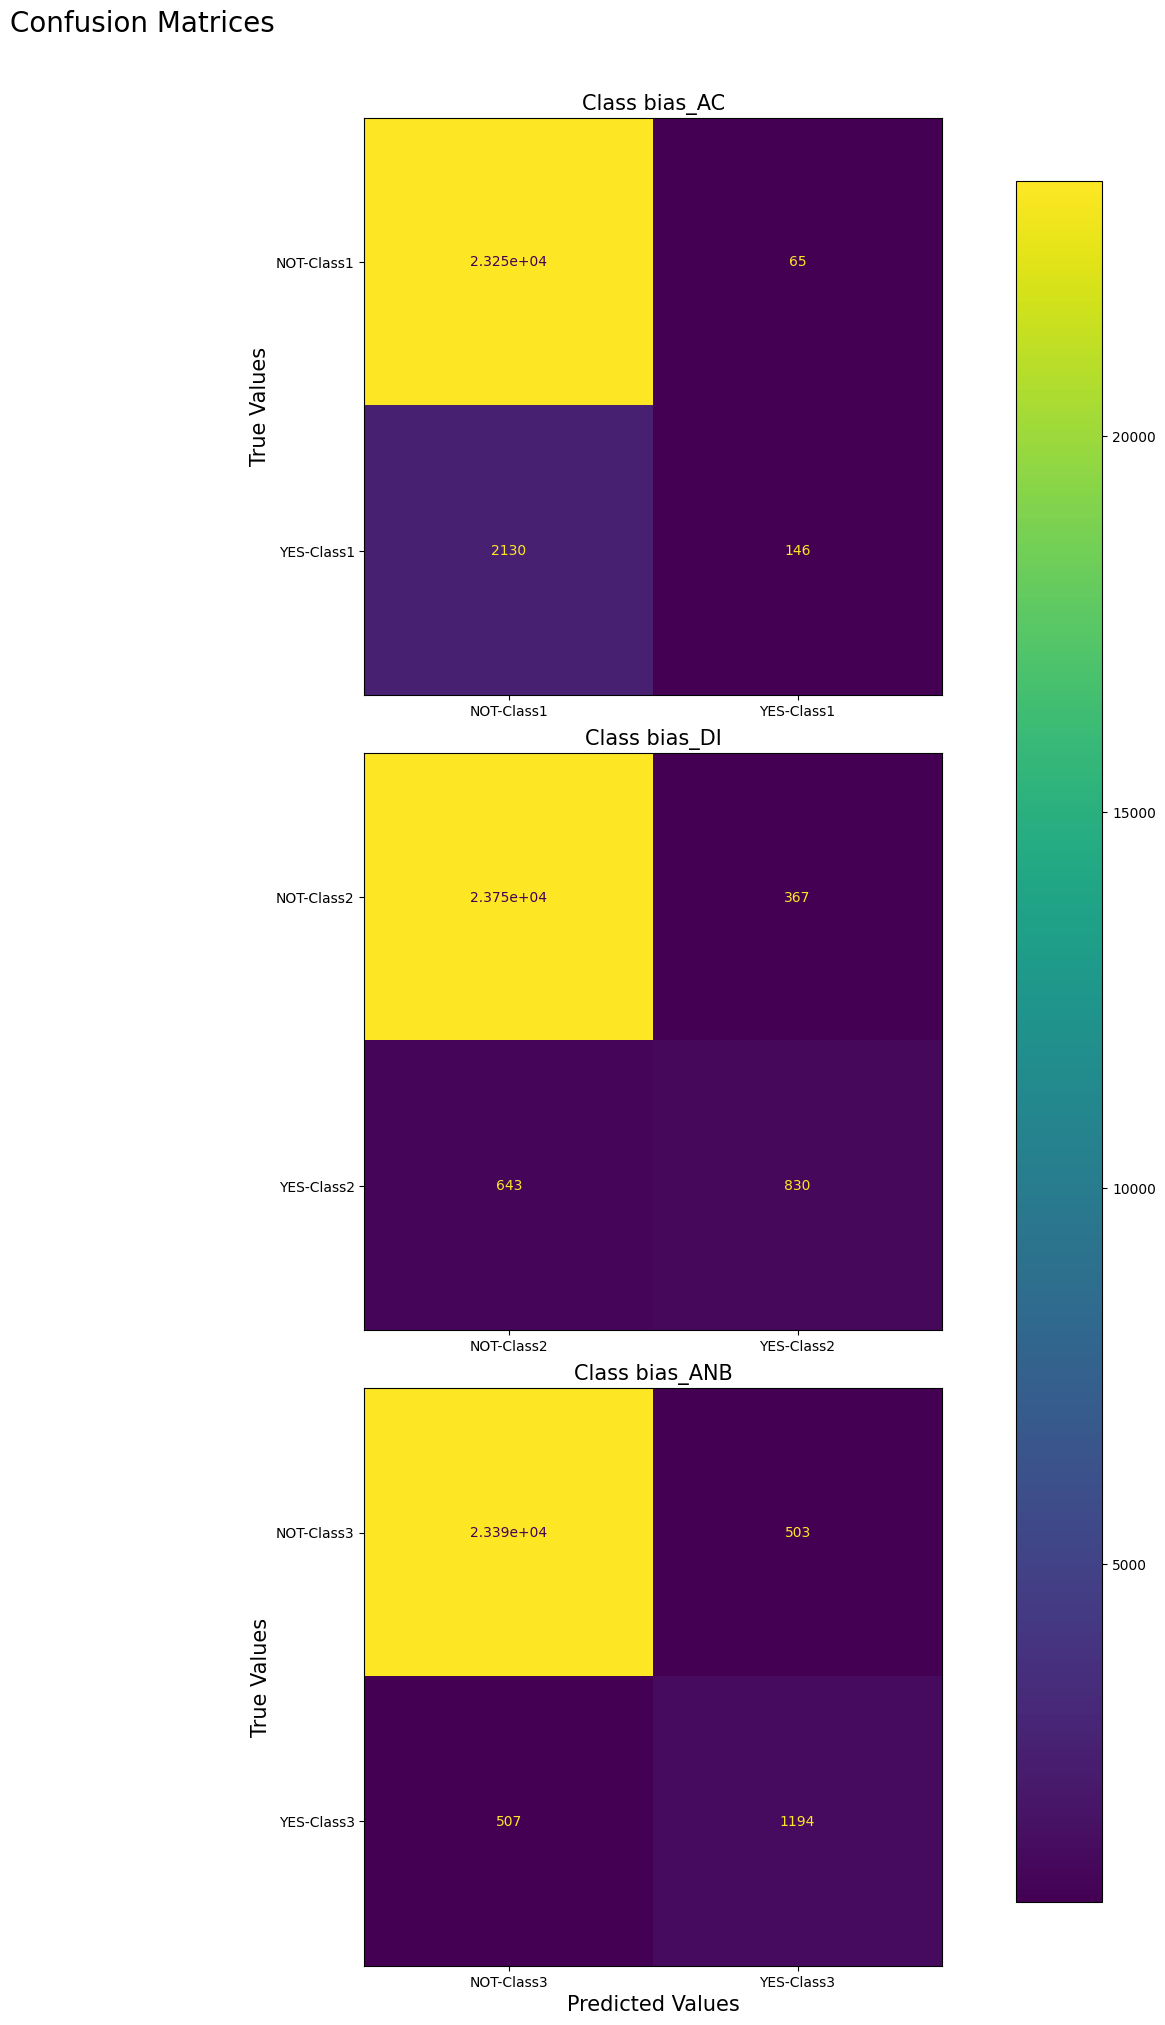

In [18]:
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(24, 24))
axes = axes.ravel()
for i in range(len(labels)):
  y_true = [label[i] for label in test["bias_labels"].tolist()]
  y_pred = [label[i] for label in test["predicted_labels"].tolist()]
  disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=[f"NOT-Class{i+1}", f"YES-Class{i+1}"])
  disp.plot(ax=axes[i], values_format='.4g')
  disp.ax_.set_title("Class {}".format(labels[i]), fontsize=15)  
  if i<2:
    disp.ax_.set_xlabel('')  
  else:
    disp.ax_.set_xlabel('Predicted Values', fontsize=15)  
  if i%2!=0:
    disp.ax_.set_ylabel('')  
  else:
    disp.ax_.set_ylabel('True Values', fontsize=15)
  disp.im_.colorbar.remove()
plt.subplots_adjust(wspace=0.25, hspace=0.1)
fig.colorbar(disp.im_, ax=axes, fraction=0.04625, pad=0.04)
plt.suptitle("Confusion Matrices", fontsize=20, y=0.925)
plt.show()

C:\Users\wangkongqiang\AppData\Local\Temp\ipykernel_17772\539791059.py:8: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", color = "darkblue", linestyle = "--", label = "Random Classifier (AUC = 0.5)") # AUC: Area Under Curve
C:\Users\wangkongqiang\AppData\Local\Temp\ipykernel_17772\539791059.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", color = "darkblue", linestyle = "--", label = "Random Classifier (AUC = 0.5)") # AUC: Area Under Curve


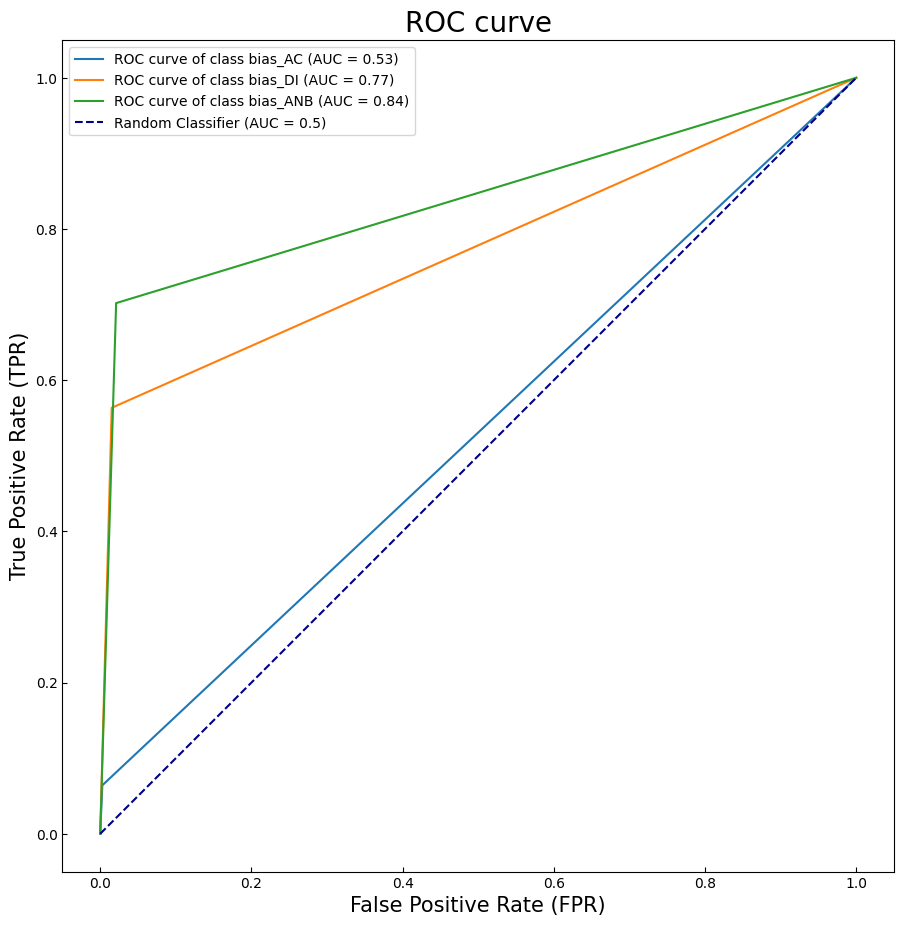

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
fig = plt.figure(figsize = (10.8, 10.8))
for i in range(len(labels)):
  y_true = [label[i] for label in test["bias_labels"].tolist()]
  y_pred = [label[i] for label in test["predicted_labels"].tolist()]
  fpr, tpr, _ = roc_curve(y_true, y_pred)
  plt.plot(fpr, tpr, label="ROC curve of class {} (AUC = {:0.2f})".format(labels[i], auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], "k--", color = "darkblue", linestyle = "--", label = "Random Classifier (AUC = 0.5)") # AUC: Area Under Curve
plt.axis("square")
plt.xlabel("False Positive Rate (FPR)", fontsize = 15)
plt.ylabel("True Positive Rate (TPR)", fontsize = 15)
plt.title("ROC curve", fontsize = 20)
plt.tick_params(axis = "y",direction = "in")
plt.tick_params(axis = "x",direction = "in")
plt.legend()
plt.show()

# test

best_ensemble: max weighted_f1  

In [20]:
test = pd.DataFrame(load_dataset("public_data/train/track_a/eng_test", split="test"))

Generating test split: 200 examples [00:00, 8588.55 examples/s]


In [21]:
f1_scores = {ensemble_name: ensembles[ensemble_name]["metrics"].get("weighted_f1") for ensemble_name in ensemble_evaluation}
best_ensemble_name = max(f1_scores, key=f1_scores.get)
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble05',
 'models': ['distilbert-multi'],
 'metrics': {'accuracy': 0.86995,
  'macro_f1': 0.48063,
  'macro_precision': 0.69631,
  'macro_recall': 0.44319,
  'weighted_f1': 0.43641}}

In [22]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

1it [00:02,  2.72s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 51.52it/s]


In [23]:
test["bias_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels
0,霍尊称自己是“极端主义”，认为女人就该有女人的样子，不然“会把她打死”，并称“我断定我肯定会...,"[0, 0, 1]"
1,文案职位仅招男性，因为需要出差。,"[0, 0, 0]"
2,好像所有女人在工作之前都得变美，一个女人打扮是肤浅，而不打扮是没礼貌。,"[1, 0, 0]"
3,如果第一个登上月球的是女性，她可能也要穿高跟鞋。,"[0, 0, 0]"
4,受传统观念和生理条件影响，育儿和承担家庭责任被视为女性天职。,"[0, 0, 0]"
5,授课人莫兰说，大自然给了男性接受外部挑战的理想条件，所以男人要在社会、家庭生活中担任好“领导...,"[1, 0, 0]"
6,中国女人挑选男人的标准是男人要会赚钱，至于良心好不好不管，所以中国女性的堕落导致了国家的堕落。,"[1, 0, 0]"
7,一开学术会议，男博士们都在研究课题，女博士则聊多大生小孩，痛诉“血泪史”。,"[0, 0, 0]"
8,比起男人和男孩之间的轻易合作，女性之间更容易在社交场合出现相互排挤的现象。,"[0, 0, 0]"
9,戏剧故事中，女性过了30岁就开始不为自己而活，或是围绕儿女做个讨人嫌的母亲（这样还能有点存在...,"[0, 0, 0]"


In [24]:
best_ensemble.get("models")[0]

'distilbert-multi'

In [25]:
test.to_csv(f"test_submission_{best_ensemble.get('models')[0]}.csv",index = False)

best_ensemble: max macro_precision

In [27]:
# f1_scores = {ensemble_name: ensembles[ensemble_name]["metrics"].get("macro_precision") for ensemble_name in ensemble_evaluation}
# best_ensemble_name = max(f1_scores, key=f1_scores.get)
best_ensemble_name = 'ensemble14'
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble14',
 'models': ['mbert-uncased', 'distilbert-multi'],
 'metrics': {'accuracy': 0.8612,
  'macro_f1': 0.41343,
  'macro_precision': 0.44488,
  'macro_recall': 0.38673,
  'weighted_f1': 0.36336}}

In [28]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

1it [00:02,  2.59s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 35.12it/s]
1it [00:02,  2.55s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 58.33it/s]


In [29]:
test["bias_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels
0,霍尊称自己是“极端主义”，认为女人就该有女人的样子，不然“会把她打死”，并称“我断定我肯定会...,"[0, 1, 1]"
1,文案职位仅招男性，因为需要出差。,"[0, 0, 0]"
2,好像所有女人在工作之前都得变美，一个女人打扮是肤浅，而不打扮是没礼貌。,"[0, 0, 0]"
3,如果第一个登上月球的是女性，她可能也要穿高跟鞋。,"[0, 0, 0]"
4,受传统观念和生理条件影响，育儿和承担家庭责任被视为女性天职。,"[0, 0, 0]"
5,授课人莫兰说，大自然给了男性接受外部挑战的理想条件，所以男人要在社会、家庭生活中担任好“领导...,"[0, 0, 0]"
6,中国女人挑选男人的标准是男人要会赚钱，至于良心好不好不管，所以中国女性的堕落导致了国家的堕落。,"[0, 0, 0]"
7,一开学术会议，男博士们都在研究课题，女博士则聊多大生小孩，痛诉“血泪史”。,"[0, 0, 0]"
8,比起男人和男孩之间的轻易合作，女性之间更容易在社交场合出现相互排挤的现象。,"[0, 0, 0]"
9,戏剧故事中，女性过了30岁就开始不为自己而活，或是围绕儿女做个讨人嫌的母亲（这样还能有点存在...,"[0, 0, 0]"


In [30]:
best_ensemble.get("models")[0]+'--'+best_ensemble.get("models")[1]

'mbert-uncased--distilbert-multi'

In [31]:
test.to_csv(f"test_submission_{best_ensemble.get('models')[0]+'--'+best_ensemble.get('models')[1]}.csv",index = False)

best_ensemble: ensemble50	 

In [32]:
best_ensemble_name = 'ensemble50'
best_ensemble = {"name": best_ensemble_name,                 
"models": ensembles[best_ensemble_name].get("models"),                 
"metrics": ensembles[best_ensemble_name].get("metrics")                 
}
best_ensemble

{'name': 'ensemble50',
 'models': ['mbert-cased', 'beto-cased', 'beto-uncased', 'distilbert-multi'],
 'metrics': {'accuracy': 0.86264,
  'macro_f1': 0.46004,
  'macro_precision': 0.67234,
  'macro_recall': 0.44156,
  'weighted_f1': 0.41489}}

In [33]:
for model_name in best_ensemble.get("models"):
  model_predictions, model_raw_outputs = models.get(model_name).predict(test["ori_sentence"].tolist())
  model_evaluation[model_name]["test_model_outputs"] = model_raw_outputs
  model_evaluation[model_name]["test_predictions"] = list ()  
  for output in model_raw_outputs:
    model_evaluation[model_name]["test_predictions"].append([0 if lab_output < 0.5 else 1 for lab_output in output])
predict_ensemble(best_ensemble.get("name"), "test", test, weighted=WEIGHTED)

1it [00:02,  2.53s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 39.35it/s]
1it [00:02,  2.50s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 44.78it/s]
1it [00:02,  2.51s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 43.06it/s]
1it [00:02,  2.53s/it]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|

In [34]:
test["bias_labels"] = ensemble_evaluation[best_ensemble.get("name")].get("test_predictions")
test.head(10)

,ori_sentence,bias_labels
0,霍尊称自己是“极端主义”，认为女人就该有女人的样子，不然“会把她打死”，并称“我断定我肯定会...,"[0, 1, 1]"
1,文案职位仅招男性，因为需要出差。,"[0, 0, 0]"
2,好像所有女人在工作之前都得变美，一个女人打扮是肤浅，而不打扮是没礼貌。,"[0, 0, 1]"
3,如果第一个登上月球的是女性，她可能也要穿高跟鞋。,"[0, 0, 0]"
4,受传统观念和生理条件影响，育儿和承担家庭责任被视为女性天职。,"[0, 0, 0]"
5,授课人莫兰说，大自然给了男性接受外部挑战的理想条件，所以男人要在社会、家庭生活中担任好“领导...,"[1, 0, 0]"
6,中国女人挑选男人的标准是男人要会赚钱，至于良心好不好不管，所以中国女性的堕落导致了国家的堕落。,"[0, 0, 0]"
7,一开学术会议，男博士们都在研究课题，女博士则聊多大生小孩，痛诉“血泪史”。,"[0, 0, 0]"
8,比起男人和男孩之间的轻易合作，女性之间更容易在社交场合出现相互排挤的现象。,"[0, 0, 0]"
9,戏剧故事中，女性过了30岁就开始不为自己而活，或是围绕儿女做个讨人嫌的母亲（这样还能有点存在...,"[0, 0, 0]"


In [35]:
best_ensemble.get("models")[0]+'--'+best_ensemble.get("models")[1]+'--'+best_ensemble.get("models")[2]+'--'+best_ensemble.get("models")[3]

'mbert-cased--beto-cased--beto-uncased--distilbert-multi'

In [36]:
test.to_csv(f"test_submission_{best_ensemble.get('models')[0]+'--'+best_ensemble.get('models')[1]+'--'+best_ensemble.get('models')[2]+'--'+best_ensemble.get('models')[3]}.csv",index = False)